<a href="https://colab.research.google.com/github/hrulevskaya/ML_tasks/blob/main/4task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import accuracy_score
from sklearn import metrics
import scipy.io as spio
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


(128, 128, 3)


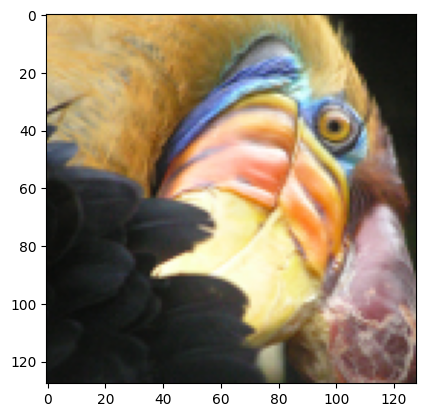

In [ ]:
pic1 = mpimg.imread('/content/gdrive/MyDrive/bird_small.png')
plt.imshow(pic1)
print(pic1.shape)

[[0.153927   0.14840925 0.1362214 ]
 [0.8899472  0.80485815 0.64765275]
 [0.6406329  0.5118657  0.35802773]]


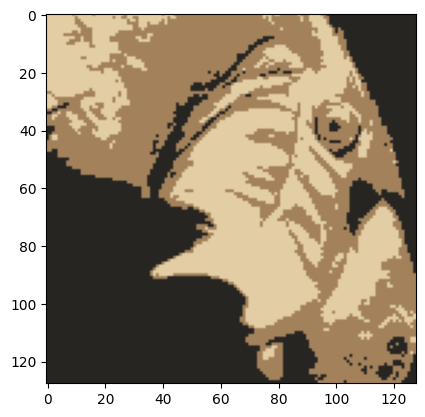

In [ ]:
rows = pic1.shape[0]
cols = pic1.shape[1]

reshaped_image = pic1.reshape(rows * cols, 3)

kmeans = KMeans(n_clusters=3)
kmeans.fit(reshaped_image)
print(kmeans.cluster_centers_)
compressed_image = kmeans.cluster_centers_[kmeans.labels_]

#compressed_image = np.clip(compressed_image.astype('uint8'), 0, 255)
compressed_image = compressed_image.reshape(rows, cols, 3)
plt.imshow(compressed_image)

In [ ]:
import os

plt.imsave('/content/gdrive/MyDrive/bird_small_compressed_kmeans.png', compressed_image)
k = os.path.getsize('/content/gdrive/MyDrive/bird_small.png') / os.path.getsize('/content/gdrive/MyDrive/bird_small_compressed_kmeans.png')
print(f"Изображение стало весить в {k:.2f} раз меньше")

Изображение стало весить в 11.42 раз меньше


16384
(16384, 3)


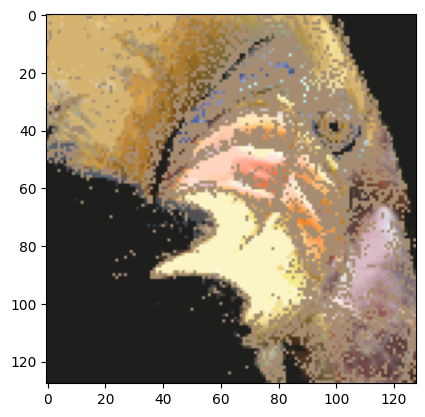

1185


In [ ]:
##################DBSCAN#########################
#d = DBSCAN(eps=0.015, min_samples=1).fit(reshaped_image)
d = DBSCAN(eps=0.01, min_samples=2).fit(reshaped_image)
labels = d.labels_
print(len(d.labels_))
clusters = [np.asarray([ind for ind, label in enumerate(d.labels_) if label == lbl]) for lbl in set(d.labels_)]
cluster_centers=np.asarray([reshaped_image[cluster].mean(axis=0) for cluster in clusters])
k = cluster_centers[d.labels_]
print(k.shape)
imgplot = plt.imshow(k.reshape(pic1.shape))
plt.show()

print(len(clusters))

In [ ]:
plt.imsave('/content/gdrive/MyDrive/bird_small_dbscan.png', k.reshape(pic1.shape))
k = os.path.getsize('/content/gdrive/MyDrive/bird_small.png') / os.path.getsize('/content/gdrive/MyDrive/bird_small_dbscan.png')
print(f"Изображение стало весить в {k:.2f} раз меньше")

Изображение стало весить в 1.47 раз меньше


(247, 330, 3)


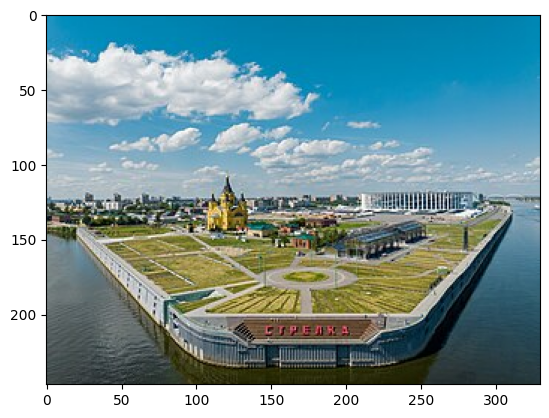

In [ ]:
pic2 = mpimg.imread('/content/gdrive/MyDrive/nn.jpg')
plt.imshow(pic2)
print(pic2.shape)

[[0.09442166 0.54411081 0.70956727]
 [0.6538345  0.711855   0.7206984 ]
 [0.29189533 0.32220086 0.258911  ]]


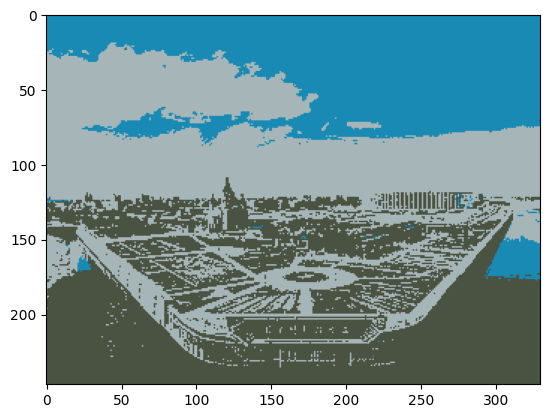

In [ ]:
rows = pic2.shape[0]
cols = pic2.shape[1]

reshaped_image = pic2.reshape(rows * cols, 3)
if reshaped_image.max() > 1:
    reshaped_image = reshaped_image / 255

kmeans = KMeans(n_clusters=3)
kmeans.fit(reshaped_image)
print(kmeans.cluster_centers_)
compressed_image = kmeans.cluster_centers_[kmeans.labels_]

#compressed_image = np.clip(compressed_image.astype('uint8'), 0, 255)
compressed_image = compressed_image.reshape(rows, cols, 3)
plt.imshow(compressed_image)

In [ ]:
plt.imsave('/content/gdrive/MyDrive/nn_compressed_kmeans.jpg', compressed_image)
k = os.path.getsize('/content/gdrive/MyDrive/nn.jpg') / os.path.getsize('/content/gdrive/MyDrive/nn_compressed_kmeans.jpg')
print(f"Изображение стало весить в {k:.2f} раз меньше")

Изображение стало весить в 1.70 раз меньше


81510
(81510, 3)


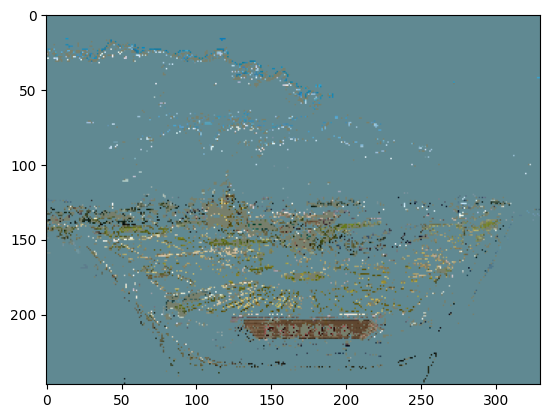

1491


In [ ]:
##################DBSCAN#########################
#d = DBSCAN(eps=0.015, min_samples=1).fit(reshaped_image)
d = DBSCAN(eps=0.01, min_samples=2).fit(reshaped_image)
labels = d.labels_
print(len(d.labels_))
clusters = [np.asarray([ind for ind, label in enumerate(d.labels_) if label == lbl]) for lbl in set(d.labels_)]
cluster_centers=np.asarray([reshaped_image[cluster].mean(axis=0) for cluster in clusters])
k = cluster_centers[d.labels_]
print(k.shape)
imgplot = plt.imshow(k.reshape(pic2.shape))
plt.show()

print(len(clusters))

In [ ]:
plt.imsave('/content/gdrive/MyDrive/nn_small_dbscan.jpg', k.reshape(pic2.shape))
k = os.path.getsize('/content/gdrive/MyDrive/nn.jpg') / os.path.getsize('/content/gdrive/MyDrive/nn_small_dbscan.jpg')
print(f"Изображение стало весить в {k:.2f} раз меньше")

Изображение стало весить в 2.37 раз меньше
